<div class="alert alert-block alert-success">
    <h1 align="center">Time Series Forecasting - Using Darts</h1>
    <h3 align="center">NBeats Model</h3>
    
<a href="https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data">
Click for more information for dataset
    </a>
</div>

<img src="https://www.plexytrade.com/blog/wp-content/uploads/2024/11/technical-analysis-time-series-analysis.jpg"
style="width:2000px;height:350px"/>

<div style="
        background-color:#e6f9e6;
        border-left:6px solid #4caf50;
        padding: 20px;
        border-radius: 8px;
        margin: 20px 0;
        font-size: 16px;
        line-height: 1.6; ">
    <h2 style="text-align: center; color: #007400; margin-top: 0;">
        Welcome to the Notebook! 
    </h2>
    <p style="text-align: justify; font-size: 15px; margin-bottom: 20px;">
This notebook explores time series forecasting on the Daily Delhi Climate dataset. We will start with an exploratory data analysis (EDA) to understand patterns in temperature, humidity, and pressure. Then, we compare two baseline models — Linear Regression and Naive Moving Average — against a more powerful NBeats model. The goal is to see how much improvement a deep learning model can bring over simple baselines. Let's dive in and evaluate their performance using MAE, MAPE, and R² scores.
    </p>
</div>

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1. Install Darts 
    </p>
</div>

In [1]:
pip install darts -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.4/411.4 kB 27.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        1.1 Import Libraries 
    </p>
</div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#---
from statsmodels.tsa.seasonal import seasonal_decompose
#---
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.utils.likelihood_models import GaussianLikelihood, QuantileRegression
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts import concatenate
from darts.metrics import mae, mape, r2_score
#---
from darts.models import NBEATSModel, LinearRegressionModel, NaiveMovingAverage
#---
import warnings
warnings.filterwarnings('ignore')

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        2. Load Dataset: 
    </p>
</div>

In [3]:
#Train 
X_train = pd.read_csv(r'/kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTrain.csv', index_col='date')
X_train = X_train.set_index(pd.to_datetime(X_train.index))
#---
#Test:
X_test = pd.read_csv(r'/kaggle/input/datasets/sumanthvrao/daily-climate-time-series-data/DailyDelhiClimateTest.csv', index_col='date')
X_test = X_test.set_index(pd.to_datetime(X_test.index))

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        2.1 Data Overview: 
    </p>
</div>

In [4]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1462 entries, 2013-01-01 to 2017-01-01
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1462 non-null   float64
 1   humidity      1462 non-null   float64
 2   wind_speed    1462 non-null   float64
 3   meanpressure  1462 non-null   float64
dtypes: float64(4)
memory usage: 57.1 KB


<hr />

In [5]:
X_train.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


<hr />

In [6]:
X_train.head(10)

,meantemp,humidity,wind_speed,meanpressure
date,,,,
2013-01-01,10.000000,84.500000,0.000000,1015.666667
2013-01-02,7.400000,92.000000,2.980000,1017.800000
2013-01-03,7.166667,87.000000,4.633333,1018.666667
2013-01-04,8.666667,71.333333,1.233333,1017.166667
2013-01-05,6.000000,86.833333,3.700000,1016.500000
2013-01-06,7.000000,82.800000,1.480000,1018.000000
2013-01-07,7.000000,78.600000,6.300000,1020.000000
2013-01-08,8.857143,63.714286,7.142857,1018.714286
2013-01-09,14.000000,51.250000,12.500000,1017.000000


<hr />

In [7]:
print(X_train.isna().sum())
print('___'*10)
print(X_test.isna().sum())

meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64
______________________________
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


<hr />

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        3. Exploratory Data Analysis & Data visualization: 
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Exploratory Visualizations of Features
         </li>
        </ul>
</div>

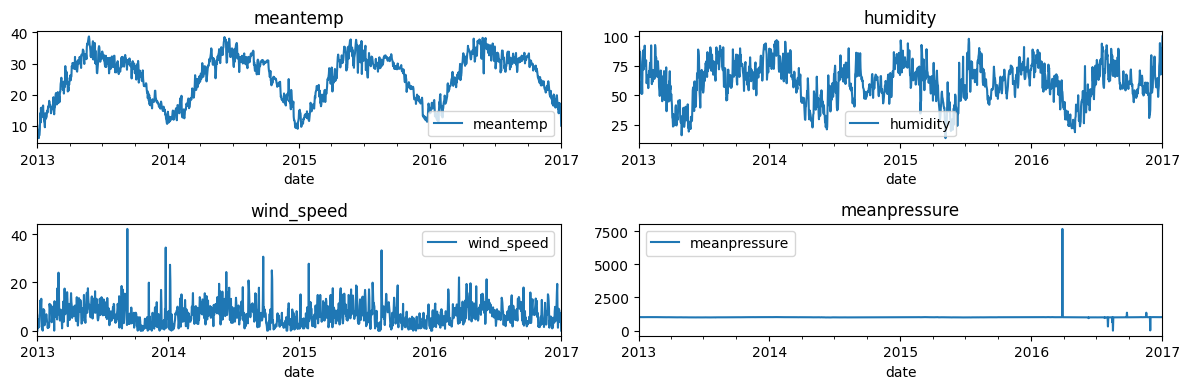

Train_Set = Firts-> 2013-01-01 : Last-> 2017-01-01
Test_Set  = Firts-> 2017-01-01 : Last-> 2017-04-24


In [8]:
#Time Series Plot:
fig, ax = plt.subplots(nrows=2,ncols=2, figsize=(12, 4))
ax = ax.flatten()  
for i, col in enumerate(X_train.columns):
    X_train[col].plot(ax=ax[i], label=col)
    ax[i].set_title(col)
    ax[i].legend()
plt.tight_layout()
plt.show()
#---
#Value range
print('Train_Set = Firts->', X_train.index.date.min(),':','Last->', X_train.index.date.max())
print('Test_Set  = Firts->', X_test.index.date.min(),':','Last->', X_test.index.date.max())

<hr />

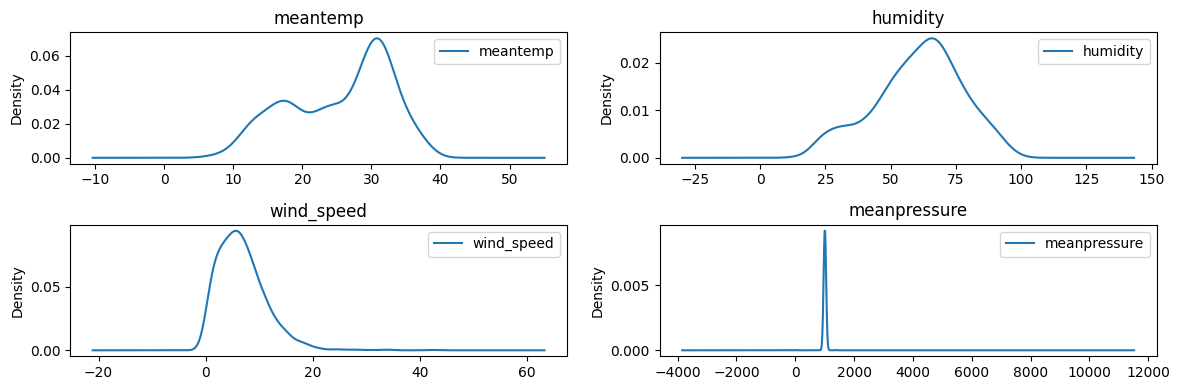

In [9]:
#Time Series hist plot
fig, ax = plt.subplots(nrows=2,ncols=2, figsize=(12, 4))
ax = ax.flatten()  
for i, col in enumerate(X_train.columns):
    X_train[col].plot(ax=ax[i], label=col, kind='kde')
    ax[i].set_title(col)
    ax[i].legend()
plt.tight_layout()
plt.show()

<hr />

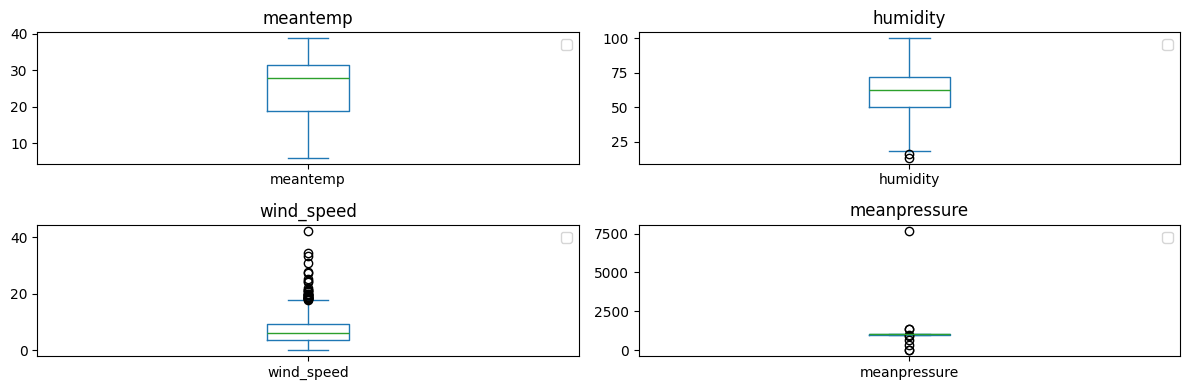

In [10]:
fig, ax = plt.subplots(nrows=2,ncols=2, figsize=(12, 4))
ax = ax.flatten()  
for i, col in enumerate(X_train.columns):
    X_train[col].plot(ax=ax[i], label=col, kind='box')
    ax[i].set_title(col)
    ax[i].legend()
plt.tight_layout()
plt.show()

<hr />

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Seasonal_Decompose(Observed - Ternd - Seasonal - Residual)
         </li>
        </ul>
</div>

In [11]:
def seasonal_decompose_plot(feature1, feature2):
    decomp_f1 = seasonal_decompose(feature1, model='additive', period=365)
    decomp_f2 = seasonal_decompose(feature2, model='additive', period=365)
    
    fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex='col')
    
    axes[0, 0].plot(decomp_f1.observed, color='royalblue')
    axes[0, 0].set_title(f'{feature1.name}')
    
    axes[1, 0].plot(decomp_f1.trend, color='royalblue')
    axes[1, 0].set_title('Trend')
    
    axes[2, 0].plot(decomp_f1.seasonal, color='royalblue')
    axes[2, 0].set_title('Seasonal')
    
    axes[3, 0].plot(decomp_f1.resid, color='royalblue')
    axes[3, 0].set_title('Residual')
    
    #---
    axes[0, 1].plot(decomp_f2.observed, color='darkorange')
    axes[0, 1].set_title(f'{feature2.name}')
    
    axes[1, 1].plot(decomp_f2.trend, color='darkorange')
    axes[1, 1].set_title('Trend')
    
    axes[2, 1].plot(decomp_f2.seasonal, color='darkorange')
    axes[2, 1].set_title('Seasonal')
    
    axes[3, 1].plot(decomp_f2.resid, color='darkorange')
    axes[3, 1].set_title('Residual')
    #---
    
    plt.suptitle('Seasonal Decomposition Comparison (Additive)', fontsize=16, y=1.02)
    plt.grid()
    plt.tight_layout()
    plt.show()

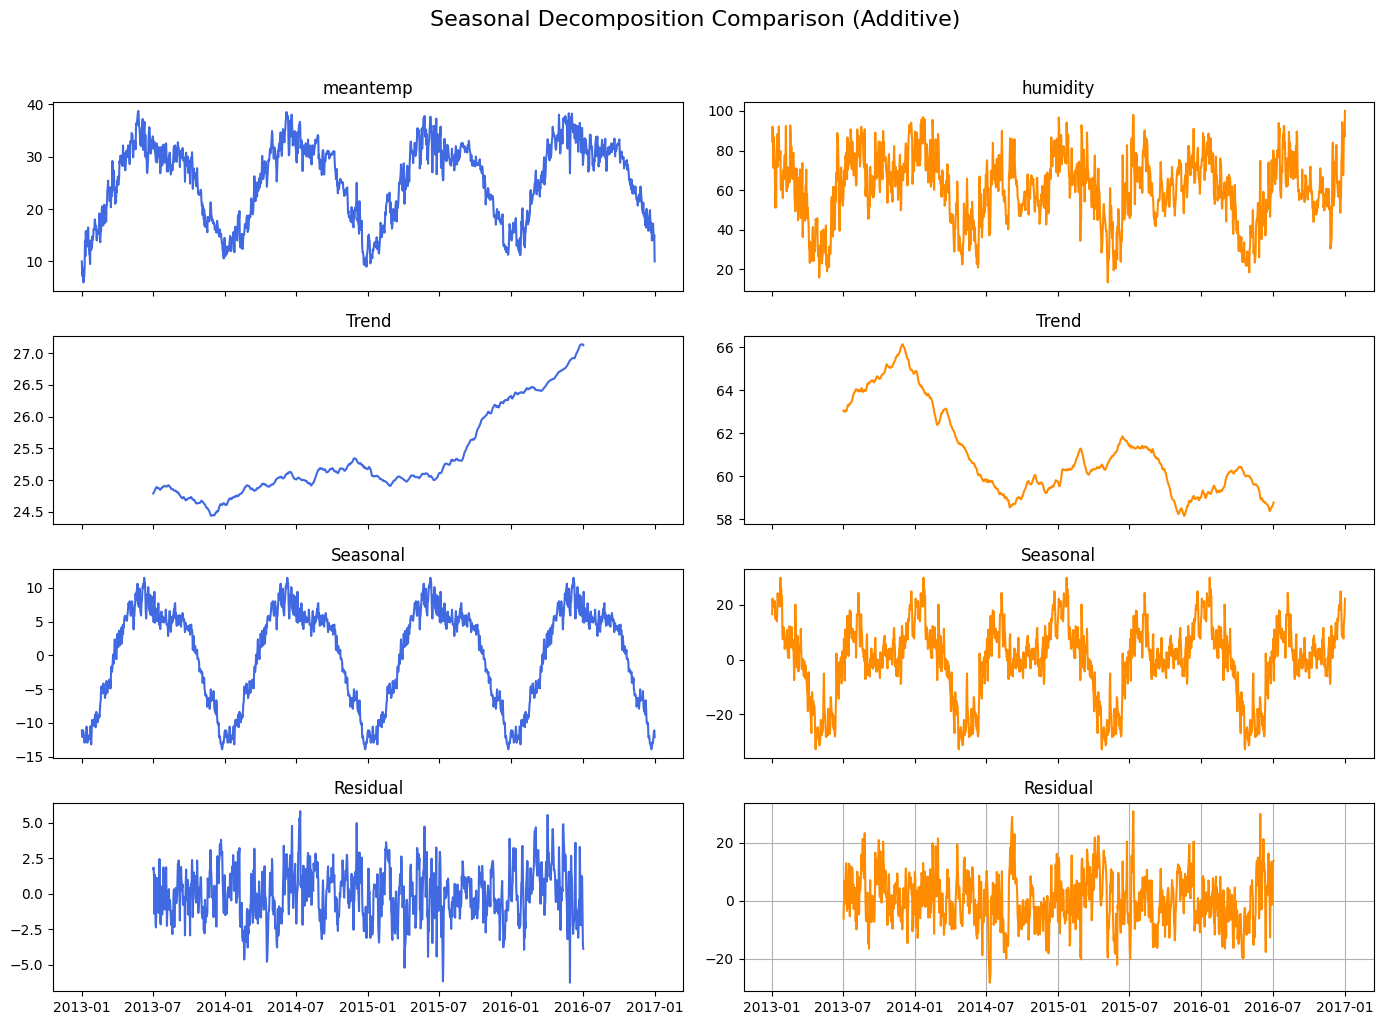

In [12]:
#meantemp - humidity
seasonal_decompose_plot(X_train.meantemp, X_train.humidity)

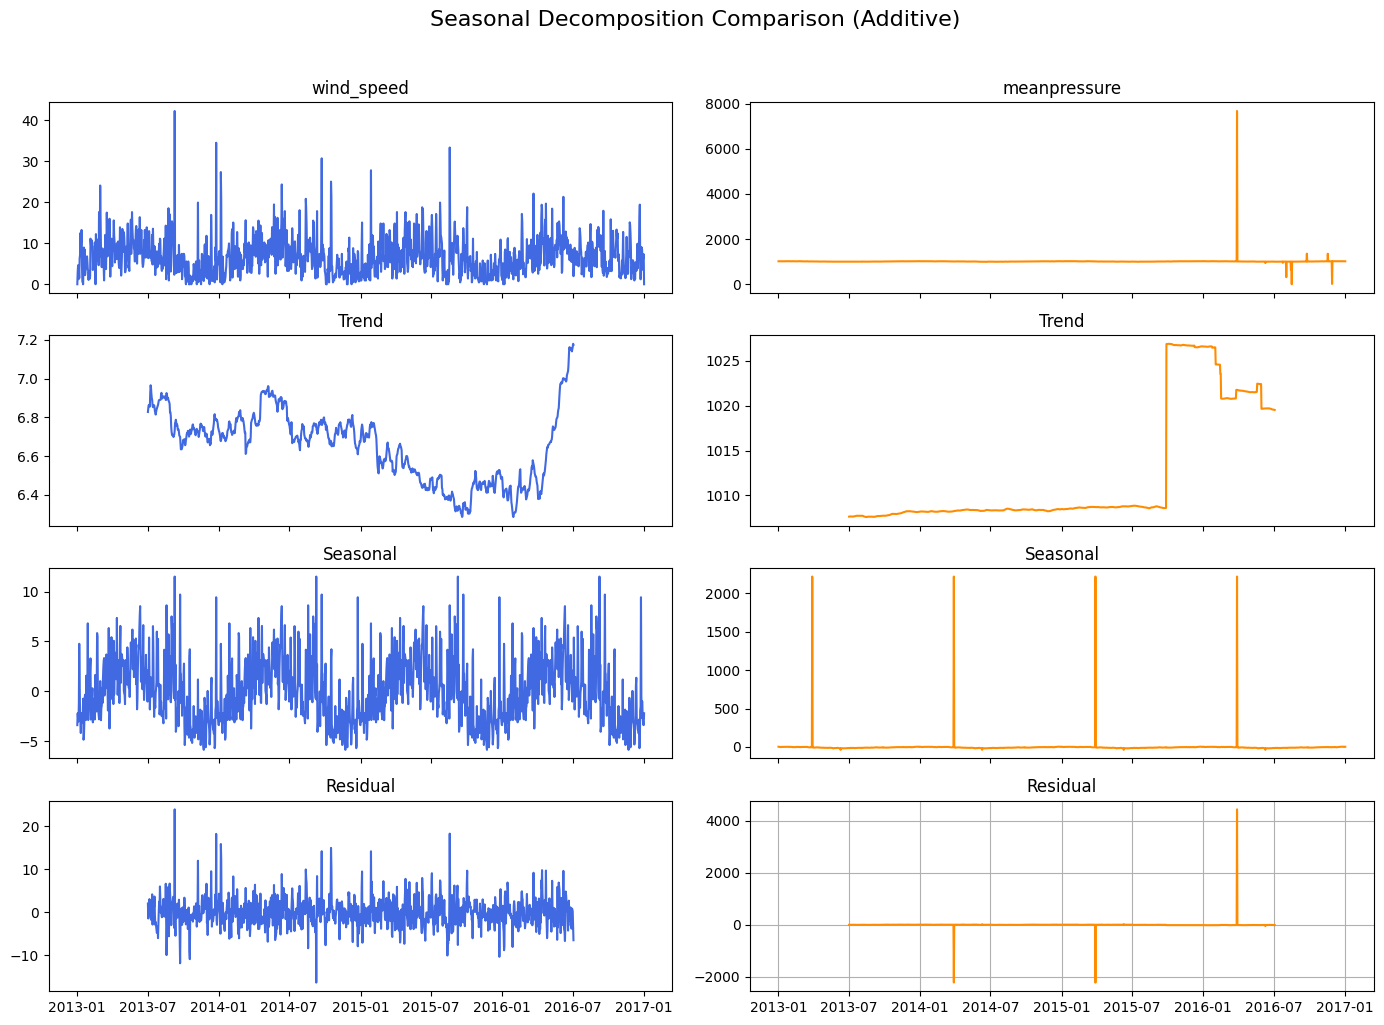

In [13]:
#meantemp - humidity
seasonal_decompose_plot(X_train.wind_speed, X_train.meanpressure)

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
The visualizations reveal several important characteristics of the Daily Climate dataset. As clearly seen in the time series plots and seasonal decomposition, the data exhibits strong annual seasonality, particularly in meantemp, which aligns with expected weather patterns in Delhi. The seasonal component is prominent and recurring, confirming clear yearly cycles in the temperature data.The KDE and box plots indicate that most variables have reasonable distributions. However, some outliers were detected — especially in meanpressure and wind_speed. These will be carefully examined during the preprocessing stage to determine whether they represent genuine extreme weather events or data quality issues that need treatment.
        </li>
    </ul>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Outlier Detection - Using IQR
         </li>
        </ul>
</div>

In [14]:
#Outlier Detection - Train Set
for col in X_train.columns :
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    print(f'{col}= lower:{lower}, upper:{upper}')
    outliers = X_train[(X_train[col] < lower) | (X_train[col] > upper)]
    print(outliers[col])
    print(f"{col}: {len(outliers)} outliers")
    print("*"*80)

meantemp= lower:0.18415178571428825, upper:49.97879464285714
Series([], Name: meantemp, dtype: float64)
meantemp: 0 outliers
********************************************************************************
humidity= lower:17.609375, upper:104.984375
date
2013-05-01    15.857143
2015-05-07    13.428571
Name: humidity, dtype: float64
humidity: 2 outliers
********************************************************************************
wind_speed= lower:-5.169852941176471, upper:17.883088235294117
date
2013-03-01    24.066667
2013-08-24    18.525000
2013-09-09    42.220000
2013-11-08    19.912500
2013-12-25    34.487500
2014-01-06    27.337500
2014-01-07    20.600000
2014-05-23    19.450000
2014-06-12    24.325000
2014-07-28    18.050000
2014-08-13    20.825000
2014-08-14    18.512500
2014-09-23    30.685714
2014-10-17    25.012500
2014-10-18    21.300000
2015-01-28    27.775000
2015-06-09    18.750000
2015-06-10    18.050000
2015-06-11    18.287500
2015-07-25    19.912500
2015-08-19    33

<hr />

In [15]:
#Outlier Detection for Test Set
for col in X_test.columns :
    q1 = X_test[col].quantile(0.25)
    q3 = X_test[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    print(f'{col}= lower:{lower}, upper:{upper}')
    outliers = X_test[(X_test[col] < lower) | (X_test[col] > upper)]
    print(outliers[col])
    print(f"{col}: {len(outliers)} outliers")
    print("*"*80)

meantemp= lower:-0.4650405452035926, upper:44.60759575569358
Series([], Name: meantemp, dtype: float64)
meantemp: 0 outliers
********************************************************************************
humidity= lower:-8.791666666666657, upper:120.31944444444443
Series([], Name: humidity, dtype: float64)
humidity: 0 outliers
********************************************************************************
wind_speed= lower:-1.1942708333333334, upper:16.8265625
date
2017-03-26    17.590000
2017-04-10    19.314286
Name: wind_speed, dtype: float64
wind_speed: 2 outliers
********************************************************************************
meanpressure= lower:993.484375, upper:1030.6927083333335
date
2017-01-01    59.0
Name: meanpressure, dtype: float64
meanpressure: 1 outliers
********************************************************************************


<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <p style="margin-bottom:10px;padding-left:15px;text-align: justify;">
        Outlier analysis using the IQR method revealed the presence of anomalous values in several features. For humidity and especially wind_speed, the detected outliers appear to represent genuine extreme weather events (such as storms or unusual wind conditions) and will therefore be retained as they contain valuable information.
    </p>
     <p style="margin-bottom:10px;padding-left:15px;text-align: justify;">
       However, the meanpressure feature contains several unrealistic and erroneous values (e.g., 7679, 310, -3, and 12 hPa), which are clearly invalid. These values are considered true outliers resulting from data entry errors or sensor issues.
    </p>
       <p style="margin-bottom:10px;padding-left:15px;text-align: justify;font-weight:bold;">
Handling Strategy:
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
            We will keep the outliers in humidity and wind_speed.
        </li>
         <li>
            For meanpressure, we will replace the erroneous values using linear interpolation based on neighboring valid observations.
        </li>
    </ul>
 <p style="margin-bottom:10px;padding-left:15px;text-align: justify;">
    This approach allows us to preserve the physical meaning and temporal continuity of the pressure time series while cleaning obvious data quality issues.
    </p>



</div>

<hr />

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        4. Data Preparation: 
    </p>
</div>



<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Handling Outlier:
         </li>
        </ul>
</div>

In [16]:
#For Train
train_mask = ((X_train["meanpressure"] < 900) | (X_train["meanpressure"] > 1100))
X_train.loc[train_mask, "meanpressure"] = np.nan
X_train["meanpressure"] = (X_train["meanpressure"].interpolate(method="time"))

#For Test
test_mask = ((X_test["meanpressure"] < 900) | (X_test["meanpressure"] > 1100))
X_test.loc[test_mask, "meanpressure"] = np.nan
X_test["meanpressure"] = (X_test["meanpressure"].interpolate(method="time")).bfill()
#---
print(X_train["meanpressure"].isna().sum())
print(X_test["meanpressure"].isna().sum())

0
0


<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Convert Data To TimeSeries (Train and Test Series + Past Covariates)
         </li>
        </ul>
</div>

<img src="https://unit8co.github.io/darts/_images/covariates-highlevel1.png" />

<div style="
    background-color:#DCFBFC;
    border-left:6px solid #10B8BC;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
    <p style="font-weight:bold;margin-bottom:10px;">
        Description:
    </p>
    <p style="margin-bottom:10px;padding-left:15px;text-align: justify;">
In this project, we utilize covariates (also known as exogenous variables) to enhance the forecasting performance of the N-BEATS model.
    </p>
    <ul style="margin:0;padding-left:20px; text-align:justify;">
        <li>
Past Covariates: These are external variables whose historical values are known up to the current time. In this project, we use past values of humidity, wind_speed, and meanpressure as past covariates. These features help the model learn how previous weather conditions affect future temperature.
        </li>
         <li>
Future Covariates (Known Future Inputs): These are variables whose future values are known in advance, such as calendar-based features (day of the year, month, season, trigonometric transformations, etc.). Although these features are generally very useful in time series forecasting and can greatly help the model capture seasonality, the N-BEATS architecture in this implementation does not utilize future covariates.
        </li>
    </ul>
    <br />
     <p style="margin-bottom:10px;padding-left:15px;text-align: justify;">
Therefore, we only use Past Covariates (humidity, wind_speed, and meanpressure) to improve the model's understanding of recent weather conditions and their impact on future temperature (meantemp).
    </p>
</div>

In [17]:
train_series = TimeSeries.from_dataframe(X_train[:-1], value_cols='meantemp', freq='D').astype(np.float32)
test_series = TimeSeries.from_dataframe(X_test, value_cols='meantemp', freq='D').astype(np.float32)
past_covariate_train = TimeSeries.from_dataframe(X_train[:-1], value_cols=['humidity','wind_speed','meanpressure'], freq='D').astype(np.float32)
past_covariate_test = TimeSeries.from_dataframe(X_test, value_cols=['humidity','wind_speed','meanpressure'], freq='D').astype(np.float32)
#---
all_series = concatenate([train_series,test_series], axis=0)
all_past_cov = concatenate([past_covariate_train,past_covariate_test], axis=0)
#---
#---Scale All Data

# Scale Train and Test Series:
series_scaler = Scaler()
train_series_sc = series_scaler.fit_transform(train_series)
test_series_sc = series_scaler.transform(test_series)
all_series_sc = series_scaler.transform(all_series)

# Scale Past Covariates
past_cov_scaler = Scaler()
past_covariate_train_sc = past_cov_scaler.fit_transform(past_covariate_train)
past_covariate_test_sc = past_cov_scaler.transform(past_covariate_test)

all_past_cov_sc = past_cov_scaler.transform(all_past_cov)

<hr />

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        5. Modeling: 
    </p>
</div>

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       BaseLine Model1 (LinearRegressionModel)
         </li>
        </ul>
</div>

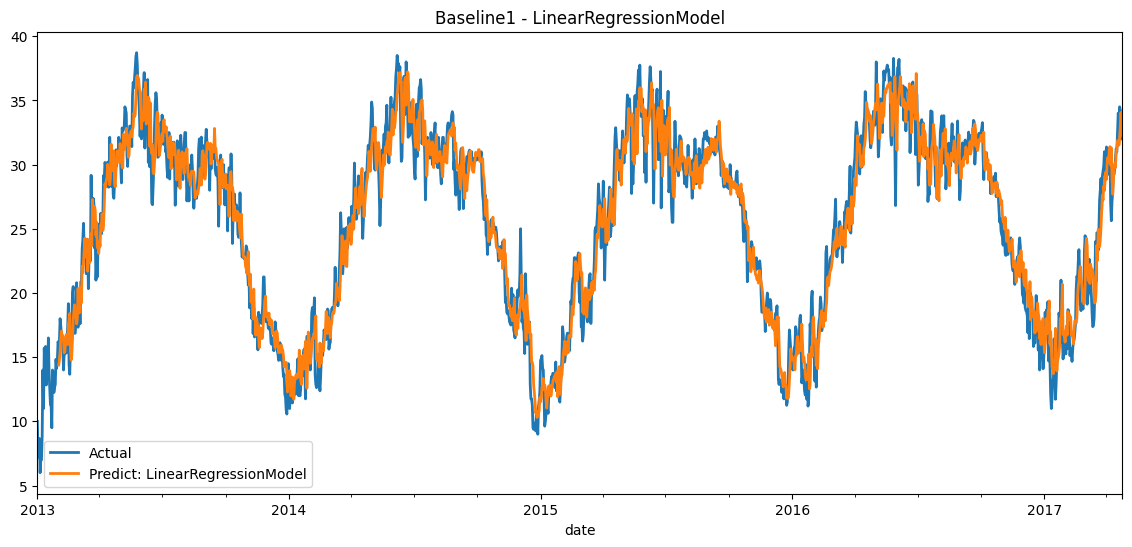

LR MAE: 1.5045289
LR MAPE: 6.55255
LR r2score: 0.9275332


In [18]:
baseline_model1 = LinearRegressionModel(
    lags=30,
    lags_past_covariates=30,
    output_chunk_length=7)
#---
baseline_model1.fit(
    series=train_series_sc,
    past_covariates=past_covariate_train_sc)

#---

#Evaluate BaseLineModel 1: - Using Historical Forecasts

lr_pred_sc = baseline_model1.historical_forecasts(
                                 series=all_series_sc,
                                 past_covariates=all_past_cov_sc,
                                 forecast_horizon=2,
                                 start=0,
                                 stride=1,
                                 retrain=False,
                                 show_warnings=False)

#---plot
lr_pred = series_scaler.inverse_transform(lr_pred_sc)
plt.figure(figsize=(14,6))
all_series.plot(label='Actual')
lr_pred.plot(label='Predict: LinearRegressionModel')
plt.title('Baseline1 - LinearRegressionModel')
plt.legend()
plt.show()

#Evaluate BaseLine Model 1 (Linear Regression) - (MAE - MAPE - R2score)

lr_mae = mae(all_series, lr_pred)
lr_mape = mape(all_series, lr_pred)
lr_r2score = r2_score(all_series, lr_pred)
print('LR MAE:', lr_mae)
print('LR MAPE:', lr_mape)
print('LR r2score:', lr_r2score)

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       BaseLine Model2 (NaiveMovingAverage)
         </li>
        </ul>
</div>

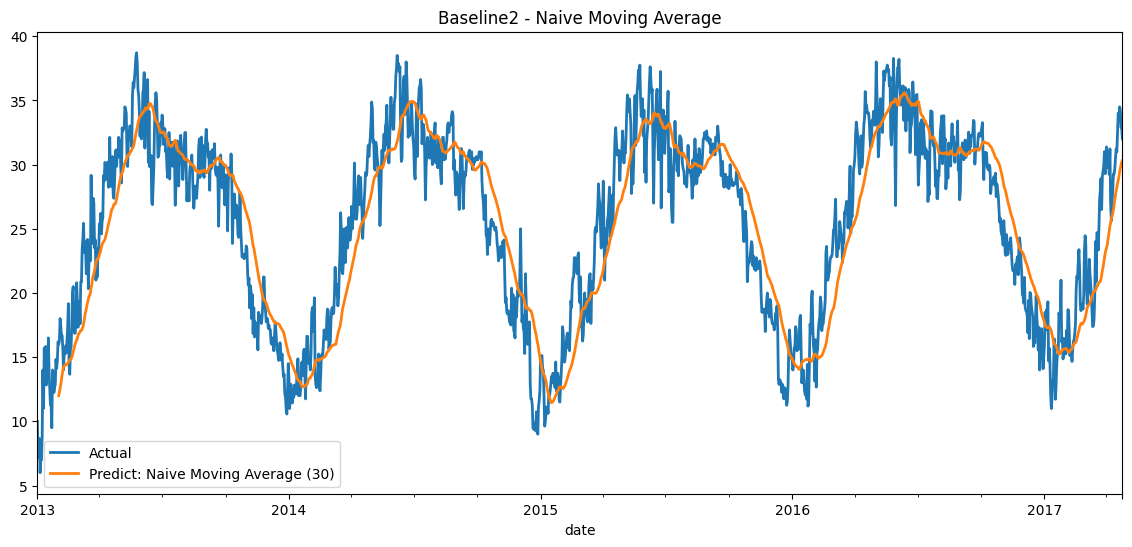

MA MAE:   2.520285249254869
MA MAPE: 11.173744196499914
MA R2:    0.8118267669804555


In [19]:
baseline_model2 = NaiveMovingAverage(input_chunk_length=30)
#---
baseline_model2.fit(series=train_series_sc)


#Evaluate BaseLineModel 2: - Using Historical Forecasts

ma_pred_sc = baseline_model2.historical_forecasts(
    series=all_series_sc,
    forecast_horizon=2,
    start=0,
    stride=1,
    show_warnings=False)

#---plot

ma_pred = series_scaler.inverse_transform(ma_pred_sc)
plt.figure(figsize=(14,6))
all_series.plot(label='Actual')
ma_pred.plot(label='Predict: Naive Moving Average (30)')
plt.legend()
plt.title('Baseline2 - Naive Moving Average')
plt.show()

#Evaluate BaseLine Model 2 (NaiveMovingAverage) - (MAE - MAPE - R2score)

ma_mae = mae(all_series, ma_pred)
ma_mape = mape(all_series, ma_pred)
ma_r2 = r2_score(all_series, ma_pred)

print('MA MAE:  ', ma_mae)
print('MA MAPE:', ma_mape)
print('MA R2:   ', ma_r2)

<div style="
    background-color:#FFFFDD;
    border-left:6px solid #FFFE00;
    padding:15px 20px;
    border-radius:8px;
    margin:15px 0;
    font-size:14px;
    line-height:1.5;
">
        <ul style="margin: 0; padding-left: 20px; text-align: justify;">
            <li>
       Orginal Model (NBeats Model)
         </li>
        </ul>
</div>

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ stacks          │ ModuleList       │  7.0 M │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 7.0 M                                                                                            
Non-trainable params: 2.0 K                                                                                        
Total params: 7.0 M                                                                                                
Total estimated model params size (MB): 27.817                                                                     
Modules in train mode: 396                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


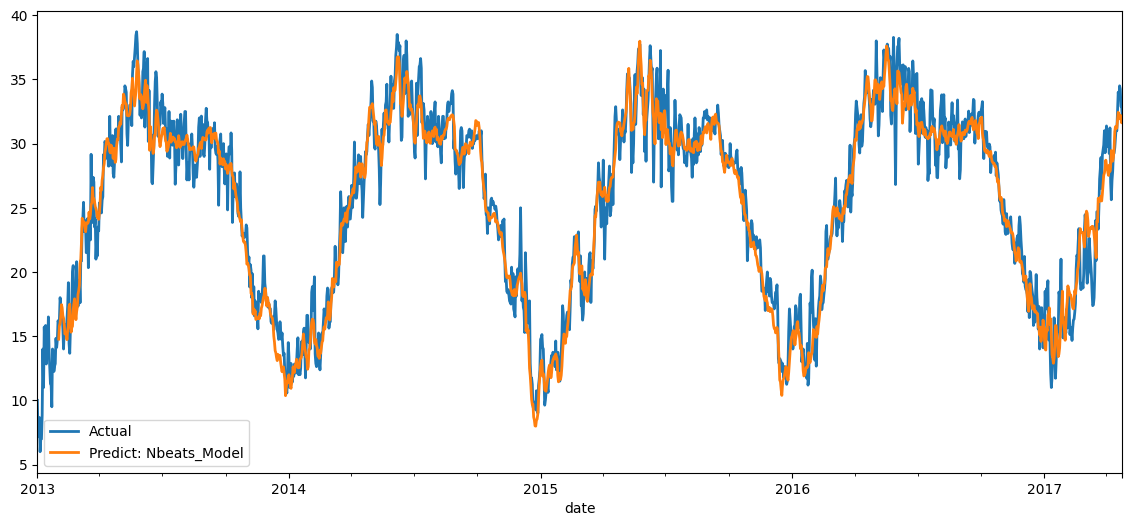

NB MAE: 1.309132
NB MAPE: 5.6687202
NB r2score: 0.9442398


In [38]:
#callbacks:
stopper = EarlyStopping(
    monitor="train_loss",
    patience=10,
    min_delta=1e-4,
    mode='min')
#---
nbeats_model = NBEATSModel(input_chunk_length=30,
                    output_chunk_length=7,
                    n_epochs=100,
                    #likelihood=GaussianLikelihood(),
                    pl_trainer_kwargs={"callbacks": [stopper]})
#---
nbeats_model.fit(series=train_series_sc, past_covariates=past_covariate_train_sc)

#NBeats Model Evaluate:

nb_pred_sc = nbeats_model.historical_forecasts(
                                 series=all_series_sc,
                                 past_covariates=all_past_cov_sc,
                                 forecast_horizon=2,
                                 start=0,
                                 stride=1,
                                 retrain=False,
                                 show_warnings=False)

#---plot
nb_pred = series_scaler.inverse_transform(nb_pred_sc)
plt.figure(figsize=(14,6))
all_series.plot(label='Actual')
nb_pred.plot(label='Predict: Nbeats_Model')
plt.legend()
plt.show()

#Evaluate Orginal Model (NBeatsModel) - (MAE - MAPE - R2score)

nb_mae = mae(all_series, nb_pred)
nb_mape = mape(all_series, nb_pred)
nb_r2score = r2_score(all_series, nb_pred)
print('NB MAE:', nb_mae)
print('NB MAPE:', nb_mape)
print('NB r2score:', nb_r2score)

<div style="background-color:#e6f9e6;border-left:6px solid #4caf50;padding:15px 20px;border-radius:8px;margin:15px 0;font-size:16px;line-height:1.5;">
    <p style="font-weight:bold;margin-bottom:10px;">
        6. Models Comparison: Baseline vs Advanced Approaches 
    </p>
</div>




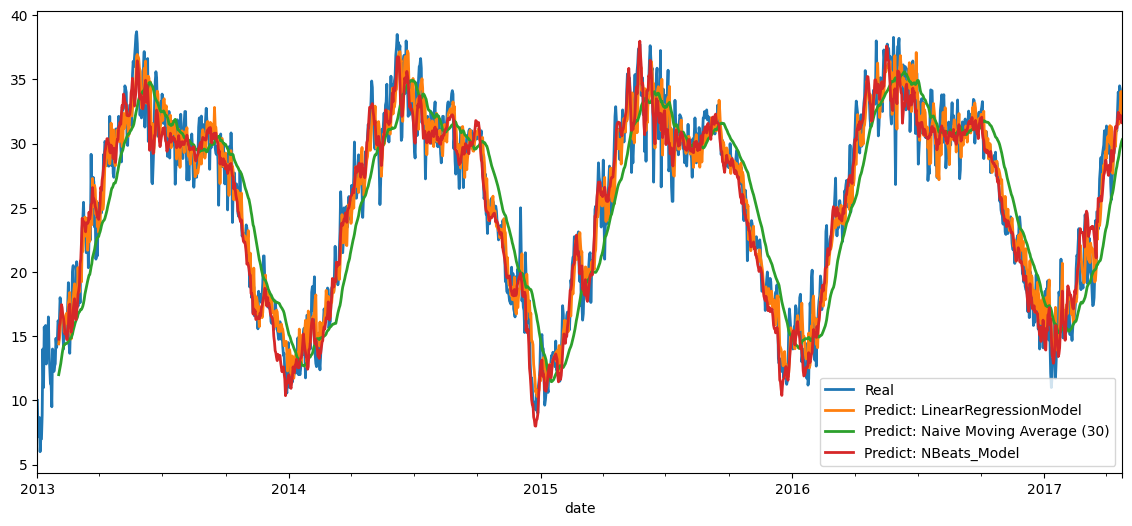

,MAE,MAPE,R² Score
Model,,,
Linear Regression,1.504529,6.552550,0.927533
Naive Moving Average,2.520285,11.173744,0.811827
NBeats_Model,1.309132,5.668720,0.944240


In [39]:
plt.figure(figsize=(14,6))
all_series.plot(label='Real')
lr_pred.plot(label='Predict: LinearRegressionModel')
ma_pred.plot(label='Predict: Naive Moving Average (30)')
nb_pred.plot(label='Predict: NBeats_Model')
plt.legend()
plt.show()
#---
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Naive Moving Average", "NBeats_Model"],
    "MAE": [lr_mae, ma_mae, nb_mae],
    "MAPE": [lr_mape, ma_mape, nb_mape],
    "R² Score": [lr_r2score, ma_r2, nb_r2score]
}).set_index("Model")

display(comparison_df)

<div
    style="
        background-color:#e6f9e6;
        border-left:6px solid #4caf50;
        padding: 20px;
        border-radius: 8px;
        margin: 20px 0;
        font-size: 16px;
        line-height: 1.6;
    "
>
    <h2 style="text-align: center; color: #4caf50; margin-top: 0;">
        Conclusion
    </h2>
    <ul style="padding-left: 25px; text-align: justify;">
        <li>
The NBeats_Model achieved the best performance with the lowest error (MAE=1.30, MAPE=5.66%) and the highest R² score (0.944). The Linear Regression model performed very similarly (MAE=1.50, R²=0.928), showing that a simple linear model can be nearly as effective. In contrast, the Naive Moving Average lagged behind (MAE=2.52, R²=0.812), highlighting the benefit of using covariates and longer lags. Given the close results, the Linear Regression model offers a fast, lightweight alternative with strong predictive accuracy.
        </li>
    </ul>
    </p>
</div>